# Notebook 3: Modelling
**Steam Sales Prediction — CIS 5450 Final Project**

Goals
─────
1. Fit and compare all baseline models (Mean, OLS, Ridge, Lasso)
2. Fit and compare advanced models (Random Forest, XGBoost)
3. Inspect Lasso feature selection and tree feature importances
4. Diagnose residuals and identify systematic errors
5. Pick the best model and report test-set performance

## 0. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from configs.config import OUTPUT_DIR, TARGET_LOG
from src.features.engineer import prepare_features
from src.models.baseline import run_all_baselines, lasso_feature_importance, make_lasso
from src.models.advanced import run_advanced_models, RandomForestModel, XGBoostModel
from src.evaluation.metrics import compare_models, residual_df, quantile_rmse

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## 1. Load preprocessed data & build feature matrix

In [2]:
df = pd.read_parquet("../outputs/processed.parquet")
print(f"Loaded: {df.shape}")

# Post-release framing (uses all observed features)
data = prepare_features(df, post_release=True, return_pipeline=True)
print(f"X_train: {data['X_train'].shape}  "
      f"X_val: {data['X_val'].shape}  "
      f"X_test: {data['X_test'].shape}")



Loaded: (115191, 84)
X_train: (80633, 80)  X_val: (17279, 80)  X_test: (17279, 80)


## 2. Baseline models

In [3]:
baseline_summary = run_all_baselines(data)
print("\nBaseline model comparison (validation set):")
baseline_summary


Baseline model comparison (validation set):


,train_RMSE_log,val_RMSE_log,test_RMSE_log,val_MAE_log,val_R2_log,val_RMSE_raw,val_MAE_raw
model,,,,,,,
MeanPredictor,3.019942,2.982177,3.017820,2.341032,-0.000033,8.339336e+05,61324.742241
LinearRegression,1.790530,1.760211,1.807455,1.372375,0.651601,2.617540e+06,116243.573272
Ridge(α=1.0),1.790531,1.760211,1.807450,1.372366,0.651601,2.617865e+06,116246.388179
Lasso(α=0.01),1.804017,1.770927,1.820642,1.378222,0.647346,2.036291e+06,100487.353644


In [ ]:
# Visualise baseline RMSE (log scale)
fig, ax = plt.subplots(figsize=(9, 4))
baseline_summary["val_RMSE_log"].sort_values(ascending=False).plot(kind="barh", ax=ax)
ax.set_xlabel("Validation RMSE (log scale)")
ax.set_title("Baseline model comparison")
plt.tight_layout()
plt.savefig("../outputs/model_baseline_rmse.png", dpi=150)
plt.show()

## 3. Lasso feature importance

In [ ]:
lasso = make_lasso()
lasso.fit(data["X_train"], data["y_train"])

lasso_imp = lasso_feature_importance(lasso, data["output_cols"], top_n=30)
print(lasso_imp.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))
lasso_imp.set_index("feature")["coef"].sort_values().plot(kind="barh", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Lasso coefficients (top 30 non-zero features)")
plt.tight_layout()
plt.savefig("../outputs/model_lasso_coefs.png", dpi=150)
plt.show()

## 4. Advanced models

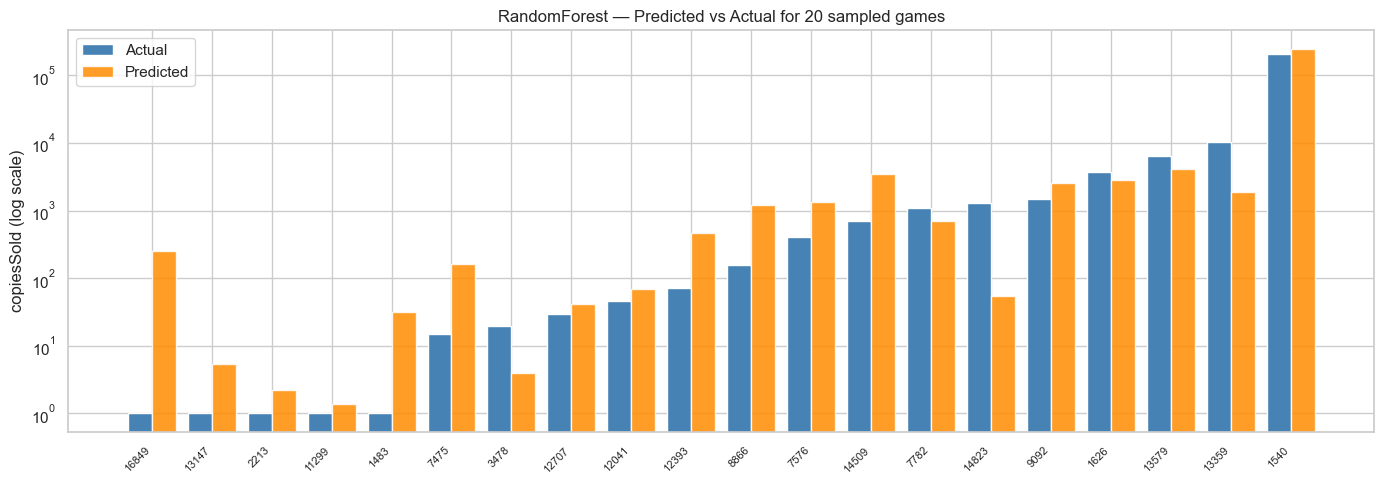

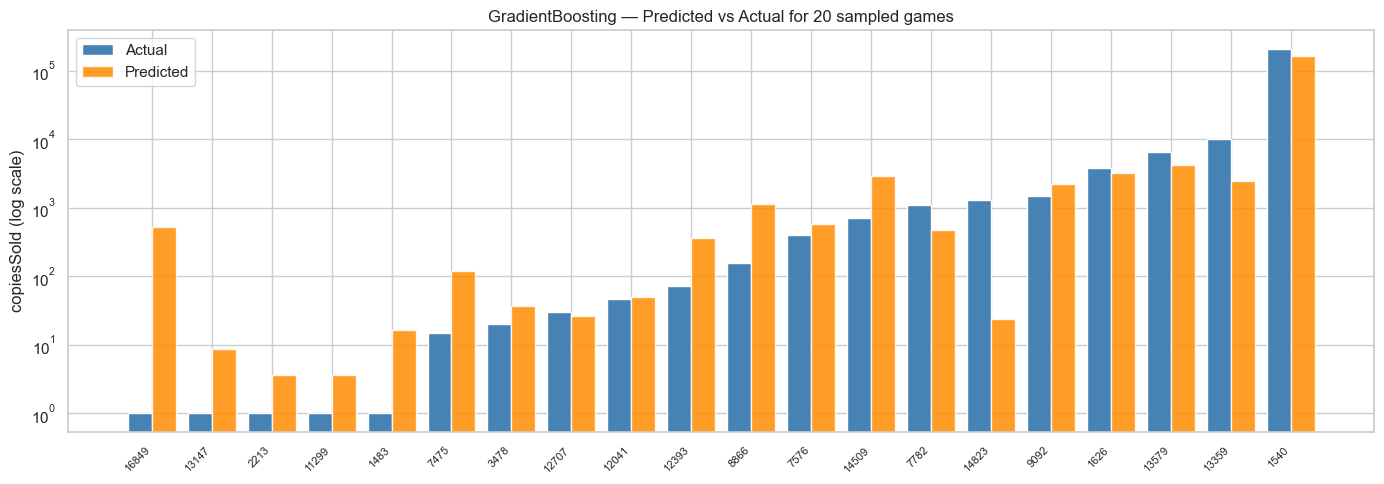

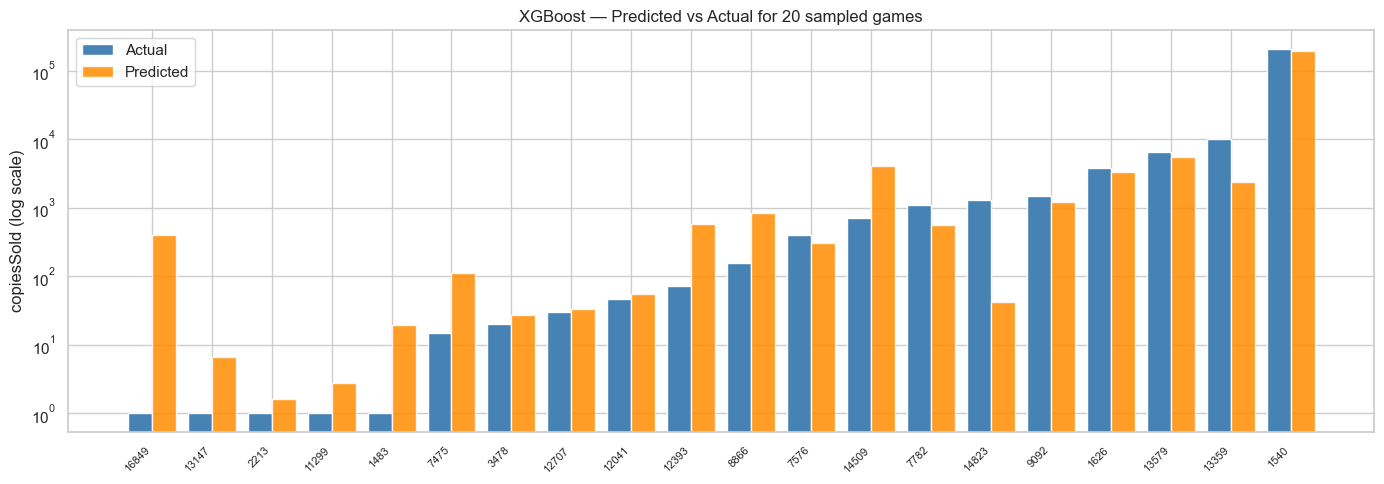

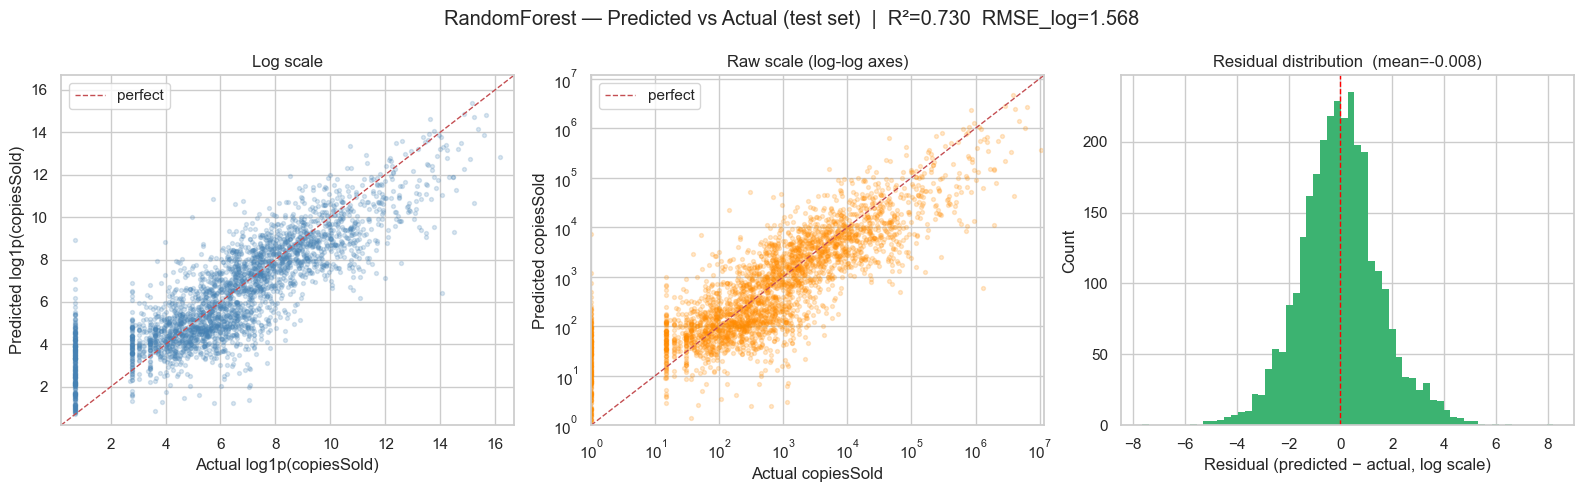

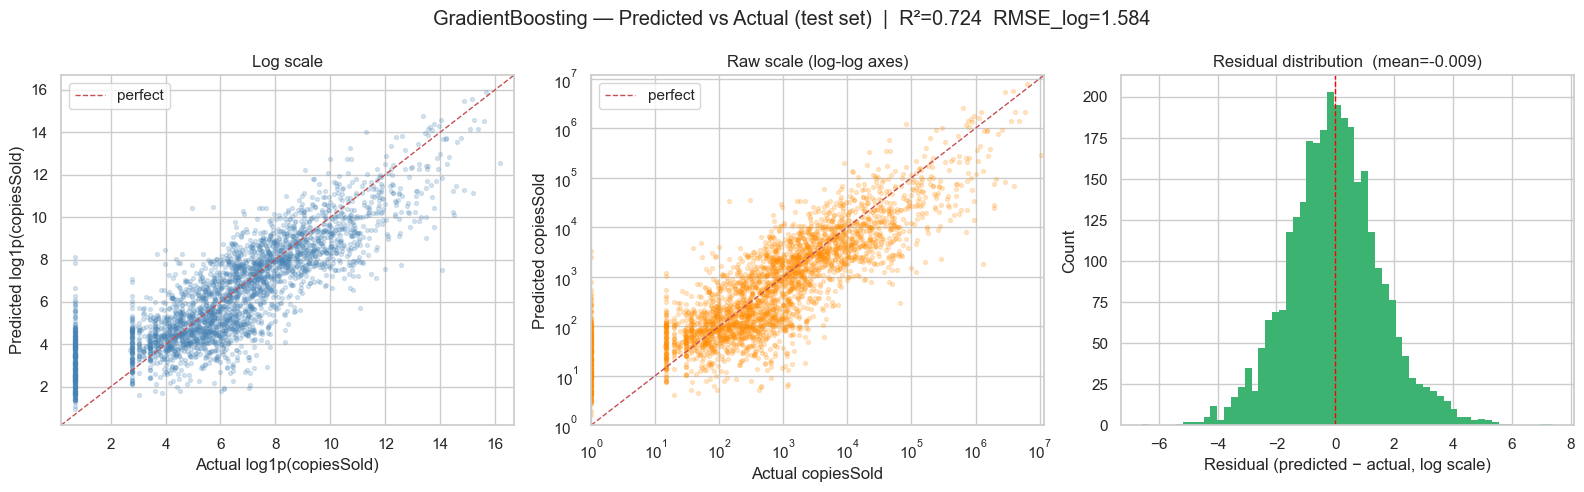

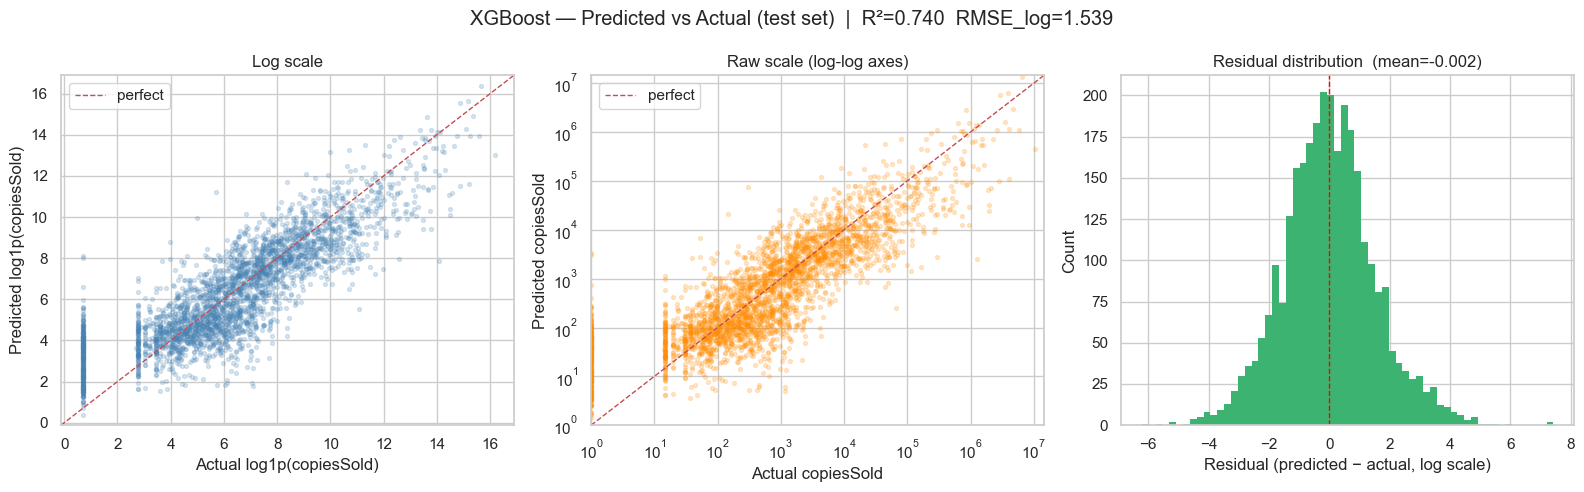

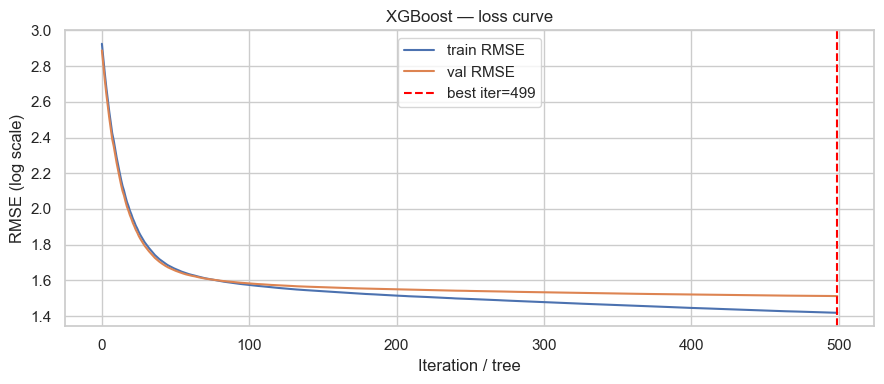

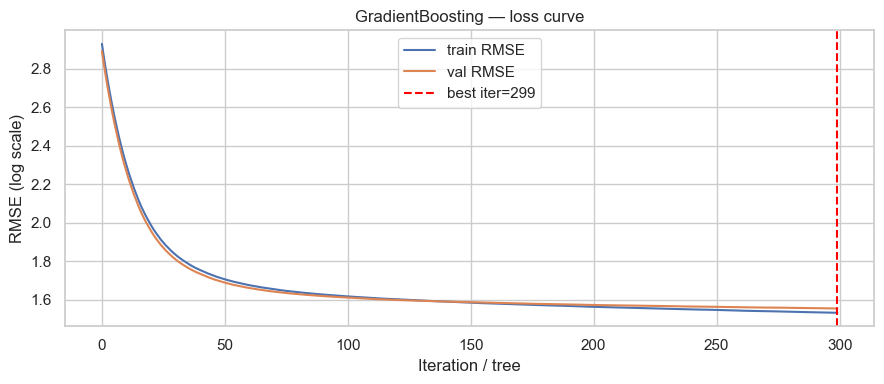

In [ ]:
summary, models = run_advanced_models(data, use_xgboost=True,save=True)


X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]


# plot predictions for any model
from src.evaluation.metrics import plot_sample_predictions
from src.evaluation.metrics import plot_predictions
for name, m in models.items():
    plot_sample_predictions(y_test, m.predict(X_test), model_name=name)
for name, m in models.items():
    plot_predictions(y_test, m.predict(X_test), model_name=name)

# loss curves for boosting models
models["XGBoost"].plot_loss_curve()
models["GradientBoosting"].plot_loss_curve()



In [4]:
import sys
sys.path.insert(0, "..")

import pandas as pd
from src.features.engineer import prepare_features

df = pd.read_parquet("../outputs/processed.parquet")
# data = prepare_features(df, post_release=True)
# # Arm 1: release_year only (current baseline)
# data_yr   = prepare_features(df, post_release=False,
#                              use_release_year=True,  use_game_age=False)

# Arm 2: game_age only
data = prepare_features(df, post_release=False,

                             use_release_year=False, use_game_age=True)



X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]


In [4]:
#Random Forest
from src.models.advanced import RandomForestModel

rf = RandomForestModel()
rf.fit(X_train, y_train)
print(rf.evaluate(X_val, y_val, "val"))

{'rmse_log': 1.545263122836881, 'mae_log': 1.1742777275666523, 'r2_log': 0.7314950565748288, 'rmse_raw': 768056.2246993397, 'mae_raw': 50383.89537251748}


In [5]:
#Gradient Boosting
from src.models.advanced import GradientBoostModel

gb = GradientBoostModel()
gb.fit(X_train, y_train)
print(gb.evaluate(X_val, y_val, "val"))


{'rmse_log': 1.5555406532065736, 'mae_log': 1.1994197269211166, 'r2_log': 0.7279115314147737, 'rmse_raw': 735314.0911678324, 'mae_raw': 47552.982946867436}


In [6]:
from src.models.advanced import XGBoostModel

xgb = XGBoostModel()
xgb.fit(X_train, y_train)
print(xgb.evaluate(X_val, y_val, "val"))


{'rmse_log': 1.512121691766639, 'mae_log': 1.1587101471913765, 'r2_log': 0.7428888611655029, 'rmse_raw': 731382.7909414622, 'mae_raw': 47642.43623951972}


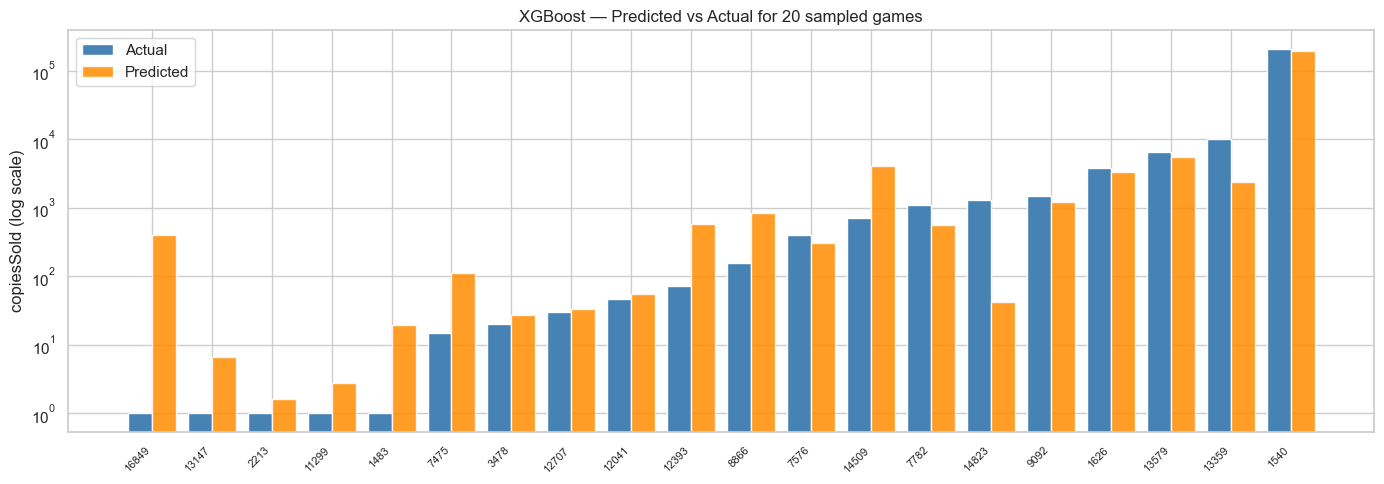

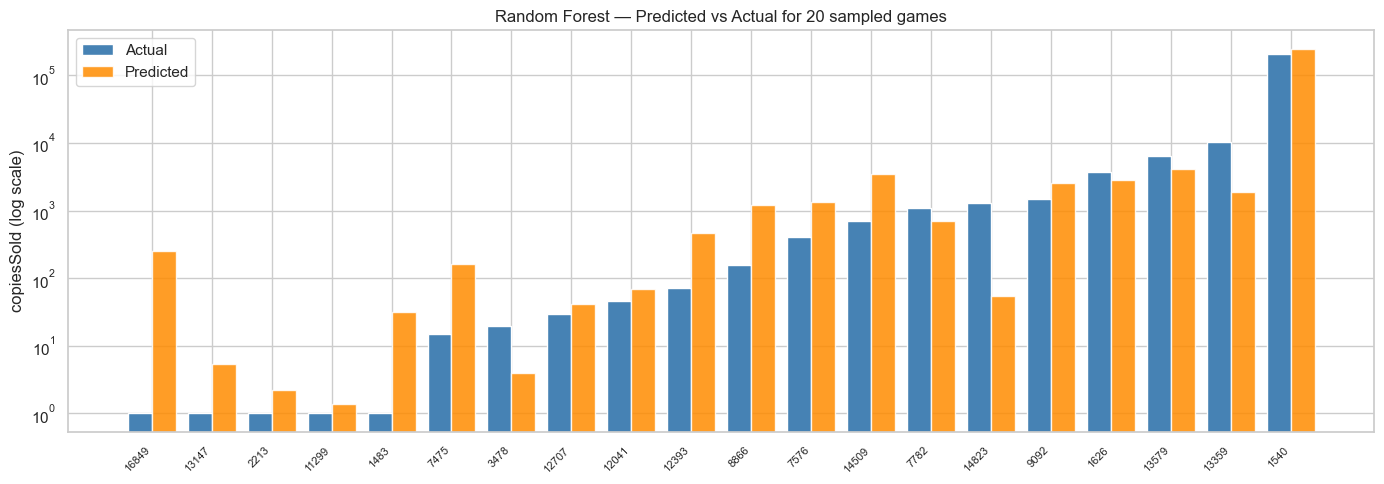

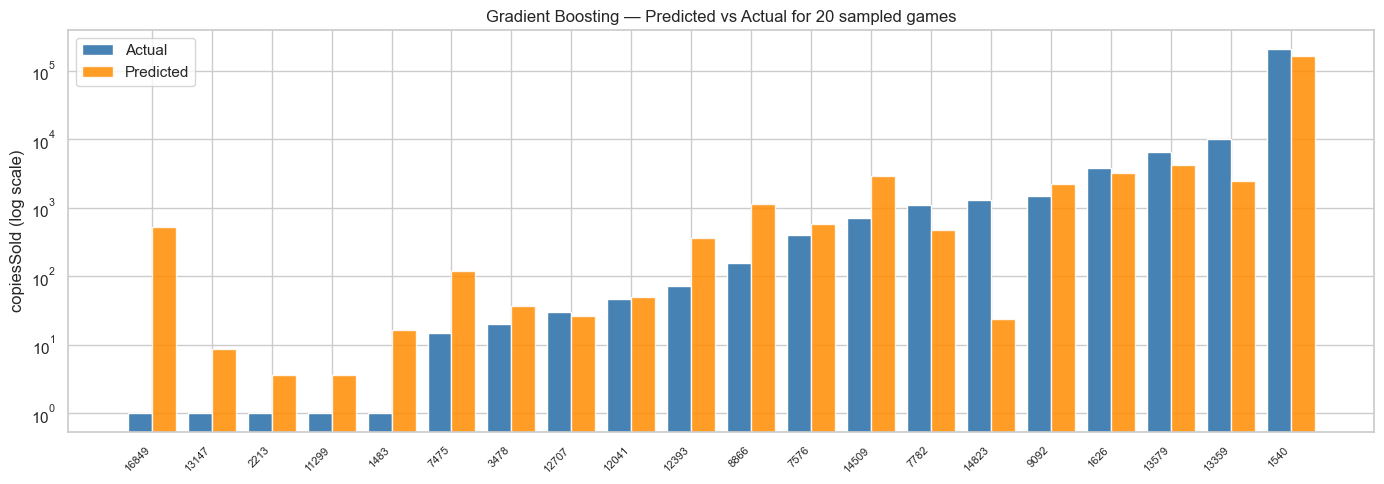

In [10]:
from src.evaluation.metrics import plot_sample_predictions
plot_sample_predictions(y_test, xgb.predict(X_test), model_name="XGBoost")
from src.evaluation.metrics import plot_sample_predictions
plot_sample_predictions(y_test, rf.predict(X_test), model_name="Random Forest")
from src.evaluation.metrics import plot_sample_predictions
plot_sample_predictions(y_test, gb.predict(X_test), model_name="Gradient Boosting")


In [ ]:
# without game names
plot_sample_predictions(y_test, xgb.predict(X_test), model_name="XGBoost")

# with game names (nicer x-axis labels)
plot_sample_predictions(y_test, xgb.predict(X_test), model_name="XGBoost", labels=test_names)

In [ ]:
# without game names
plot_sample_predictions(y_test, xgb.predict(X_test), model_name="XGBoost")

# with game names (nicer x-axis labels)
plot_sample_predictions(y_test, xgb.predict(X_test), model_name="XGBoost", labels=test_names)

## 5. Combined comparison

In [6]:
all_summary = pd.concat([baseline_summary, advanced_summary])
print("\nAll models — validation set:")
all_summary.sort_values("val_RMSE_log")

NameError: name 'baseline_summary' is not defined

In [8]:
summary.sort_values("val_RMSE_log")

,train_RMSE_log,val_RMSE_log,test_RMSE_log,val_MAE_log,val_R2_log,val_RMSE_raw,val_MAE_raw
model,,,,,,,
XGBoost,1.418283,1.512122,1.539246,1.158710,0.742889,731382.790941,47642.436240
RandomForest,1.071587,1.545263,1.568062,1.174278,0.731495,768056.224699,50383.895373
GradientBoosting,1.533100,1.555541,1.584254,1.199420,0.727912,735314.091168,47552.982947


In [ ]:
import sys
sys.path.insert(0, "..")

import pandas as pd
from src.features.engineer import prepare_features

df = pd.read_parquet("../outputs/processed.parquet")
data = prepare_features(df, post_release=True)

X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]


## 6. Best model — feature importance

In [ ]:
# Use the best-performing advanced model for feature importance
# (adapt model_name below after running the comparison above)
rf = RandomForestModel()
rf.fit(data["X_train"], data["y_train"])

rf_imp = rf.feature_importance_df(data["output_cols"], top_n=30)

fig, ax = plt.subplots(figsize=(9, 9))
rf_imp.set_index("feature")["importance"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Random Forest feature importances (top 30)")
plt.tight_layout()
plt.savefig("../outputs/model_rf_importance.png", dpi=150)
plt.show()

## 7. Residual diagnostics

In [ ]:
# Use the best model on the validation set for residual analysis
y_pred_val = rf.predict(data["X_val"])
resid = residual_df(
    np.asarray(data["y_val"]),
    y_pred_val,
    metadata=data["X_val_raw"][["publisher_class_ord"]].reset_index(drop=True)
    if "publisher_class_ord" in data["X_val_raw"].columns else None,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Predicted vs actual
axes[0].scatter(resid["y_true_log"], resid["y_pred_log"], alpha=0.15, s=6)
lo, hi = resid["y_true_log"].min(), resid["y_true_log"].max()
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1)
axes[0].set_xlabel("Actual log1p(copiesSold)")
axes[0].set_ylabel("Predicted log1p(copiesSold)")
axes[0].set_title("Predicted vs Actual")

# Residual distribution
resid["residual"].plot(kind="hist", bins=80, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (pred − actual)")
axes[1].set_title("Residual distribution")

# Residuals vs predicted
axes[2].scatter(resid["y_pred_log"], resid["residual"], alpha=0.15, s=6)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("Predicted value")
axes[2].set_ylabel("Residual")
axes[2].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.savefig("../outputs/model_residuals.png", dpi=150)
plt.show()

In [ ]:
# RMSE by sales quantile — are we better at predicting low or high sellers?
qrmse = quantile_rmse(np.asarray(data["y_val"]), y_pred_val)
print(qrmse.to_string(index=False))

## 8. Test-set evaluation (run ONCE at the very end)

⚠️  Do NOT look at the test set repeatedly.  Run the cell below only when
you have finalized your model choice.

In [ ]:
# UNCOMMENT when model is finalised:
# best_model = rf   # or xgb_model, etc.
# y_pred_test = best_model.predict(data["X_test"])
# from src.evaluation.metrics import evaluate_predictions
# test_metrics = evaluate_predictions(
#     np.asarray(data["y_test"]), y_pred_test, model_name="BestModel_TEST"
# )
# print("Test set metrics:", test_metrics)

## 9. Launch-time model (no post-release features)

For fairness of the feature comparison, also run the best model in
launch-time mode (only features observable at/before release).

In [ ]:
data_launch = prepare_features(df, post_release=False, return_pipeline=True)
print(f"Launch-time feature matrix: {data_launch['X_train'].shape}")

# TODO: re-run best model with data_launch and compare val_RMSE_log
# This lets you quantify how much post-release signal is adding.